Hyperparameter
- ITERS = 10000
- layers = [1,128,128,128,128,8]
- BATCH = 16
- NUM_HIDDEN = 1
- MOMENTUM = 0.8
- learning_rate = 1e-6
- lr_rate = [1e-3, 1e-4, 1e-6]
- lr_boundaries = [5000, 8000]

In [70]:
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal as normal

tf.keras.backend.set_floatx('float64')
tf.compat.v1.enable_eager_execution()

In [71]:
NUM_OF_INTERNAL = 60
TOTAL_T = 60
NUM_HIDDEN = 1
MOMENTUM = 0.8
BATCH = 16
K = 5
ITERS = 10000
SEED = 12345
TEXT = "beta_x0.5" #change this one

c1 = 100 
c2 = 20
c3 = 50
c4 = 200
c5 = 1000
c6 = 300*1/2

In [72]:
birth =  0.000053
death =  0.000033 

alpha = 0.00135
sigma = 0.06352
beta1 = 0.2812 /2
beta2 = 0.15838 /2
beta3 = 0.0388 /2
delta1 = 0.28505
delta2 = 0.28269
delta3 = 0.14206
gamma = 0.30954
p1 = 0.01845
p2 = 0.1431
mu = 0.0042
sigma1 = 0.09275
sigma2 = 0.03887
sigma3 = 0.07517
sigma4 = 0.06302
sigma5 = 0.07878
sigma6 = 0.06123
sigma7 = 0.0611
sigma8 = 0.06199

N = 6629870
S0 = 3674149/N
V0 = 2845438/N
E0 = 67789/N
I10 = 12113/N
I20 = 498/N
I30 = 96/N
R0 = 28911/N
D0 = 876/N

init = [S0, V0, E0, I10, I20, I30, R0, D0]

In [73]:
k0 = 0.006
k1 = -0.1341

def p1fn(alpha):
    return k0 + k1 * alpha

In [74]:
class Solver(object):

    def __init__(self, seed_var):
        self.valid_size = BATCH
        self.batch_size = BATCH
        
        self.num_iterations = ITERS
        self.print_frequency = 100
        self.lr_values = [1e-3, 1e-4, 1e-6]
        self.lr_boundaries = [5000, 8000]
        self.config = Config()

        self.model = WholeNet(seed_var)
        lr_schedule = tf.keras.optimizers.schedules.PiecewiseConstantDecay(self.lr_boundaries, self.lr_values)
        self.optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule, epsilon=1e-7)

    def train(self):
        """Training the model"""
        start_time = time.time()
        training_history = []
        control_output = [] 
        
        dW = self.config.sample(self.valid_size)
        valid_data = dW
        for step in range(self.num_iterations+1):
            if step % self.print_frequency == 0:
                cost, row_out0 = self.model(valid_data, training=True)
                elapsed_time = time.time() - start_time
                training_history.append([step, cost, elapsed_time])
                print("step: %5u, Cost: %.4e, elapsed time: %3u" % (step, cost, elapsed_time))
            if step == self.num_iterations:
                cost1, row_out1 = self.model(valid_data, training=True)
                row_output = row_out1.numpy()
                control_output.append(row_output)
            self.train_step(self.config.sample(self.batch_size))
        self.training_history = training_history
        self.control_output = control_output

    @tf.function
    def train_step(self, train_data):
        """Updating the gradients"""
        with tf.GradientTape(persistent=True) as tape:
            loss = self.model(train_data, training = True)
        grad = tape.gradient(loss, self.model.trainable_variables)
        del tape
        self.optimizer.apply_gradients(zip(grad, self.model.trainable_variables))

In [75]:
class WholeNet(tf.keras.Model):
    """Building the neural network architecture"""
    def __init__(self,seed_var):
        super(WholeNet, self).__init__()
        self.config = Config()
        self.subnet = [FNNet(seed_var) for _ in range(self.config.num_time_interval)]

    def call(self, dw, training):
        x_init = tf.ones([1, self.config.dim_x], dtype=tf.dtypes.float64) * init
        time_stamp = np.arange(0, self.config.num_time_interval) * self.config.delta_t
        all_ones = tf.ones([tf.shape(dw)[0], 1], dtype=tf.dtypes.float64)

        # initial state
        x = tf.matmul(all_ones, x_init)

        # initial cost functional
        l = 0.0 
        u_set = []
        for t in range(0, self.config.num_time_interval):
            u = self.subnet[t](x, training)
            u_set.append(tf.stack([u], axis=0))   
            l = l + self.config.f_fn(time_stamp[t], x, u) * self.config.delta_t
            x = x + self.config.b_fn(time_stamp[t], x, u) * self.config.delta_t + self.config.sigma_fn(time_stamp[t], x, u) * dw[:,:,  t]

        # control variable
        control_u = tf.stack(u_set, axis=0)
        row_ave2 = tf.reduce_mean(control_u, axis=2)
        row_out1 = tf.squeeze(row_ave2, axis=[1,2])
        #print("u timepath2", row_ave2)
        
        # terminal condition
        l = l + self.config.h_fn(self.config.total_time, x)
        cost = tf.reduce_mean(l) 
        return cost, row_out1


In [76]:
class FNNet(tf.keras.Model):
    def __init__(self, seed_var):
        super(FNNet, self).__init__()
        self.config = Config()

        tf.random.set_seed(seed_var)
        np.random.seed(seed_var)
        
        num_hiddens = [self.config.dim_x + NUM_HIDDEN, self.config.dim_x + NUM_HIDDEN, self.config.dim_x + NUM_HIDDEN]
        self.bn_layers = [
            tf.keras.layers.BatchNormalization(
                momentum=MOMENTUM,
                epsilon=1e-6,
                beta_initializer=tf.random_normal_initializer(0.0, stddev=0.1,seed=seed_var),
                gamma_initializer=tf.random_uniform_initializer(0.1, 0.5,seed=seed_var)
            )
            for _ in range(len(num_hiddens) + 2)]
        self.dense_layers = [tf.keras.layers.Dense(num_hiddens[i],
                                                   use_bias=True,
                                                   activation='tanh')
                             for i in range(len(num_hiddens))]
        
        # final output should be gradient of size dim_u
        self.dense_layers.append(tf.keras.layers.Dense(self.config.dim_u, activation='sigmoid'))

    def call(self, x, training):
        x = self.bn_layers[0](x, training)
        for i in range(len(self.dense_layers) - 1):
            x = self.dense_layers[i](x)
            x = self.bn_layers[i+1](x, training)
            x = tf.nn.tanh(x)
        x = self.dense_layers[-1](x)
        x = self.bn_layers[-1](x, training)
        return tf.nn.tanh(x) * 0.012 + 0.016

In [77]:
class Config(object):
    """function config"""
    def __init__(self):
        super(Config, self).__init__()
        self.dim_x = 8
        self.dim_u = 1
        self.num_time_interval = NUM_OF_INTERNAL
        self.total_time = TOTAL_T
        self.delta_t = (self.total_time + 0.0) / self.num_time_interval
        self.sqrth = np.sqrt(self.delta_t)
        self.t_stamp = np.arange(0, self.num_time_interval) * self.delta_t

    # sample function
    def sample(self, num_sample):
        dw_sample = normal.rvs(size=[num_sample, self.dim_x, self.num_time_interval]) * self.sqrth
        return dw_sample

    # cost functional integral item
    def f_fn(self, t, x, u):
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            alpha = u[i][0]  
            cost = (c1 * alpha ** 2 + c2 * E + (c3*I1 + c4*I2 + c5*I3) + c6 * (tf.maximum(tf.cast(0, tf.float64), 1-(S+V+R)))) 
            combined_cost = tf.stack([cost], axis=0)
            tensors.append(combined_cost)
            combined_tensor = tf.stack(tensors, axis=0)
        return tf.reduce_sum(combined_tensor, 1, keepdims=True)

    # cost fuctional terminal function
    def h_fn(self, t, x):
        return 0

    def b_fn(self, t, x, u):
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            alpha = u[i][0]
            dS = birth + (- ( beta1 * I1 + beta2 * I2 + beta3 * I3) * S  - alpha * S) - death*S
            dV = (alpha * S - sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V) - death*V
            dE = ((beta1 * I1 + beta2 * I2 + beta3 * I3) * S  + sigma * (beta1 * I1 + beta2 * I2 + beta3 * I3) * V - gamma * E) - death*E
            dI1 = (gamma * E - (delta1 + p1fn(alpha)) * I1) - death*I1
            dI2 = (p1fn(alpha) * I1 - (delta2 + p2) * I2) - death*I2
            dI3 = (p2 * I2 - (delta3 + mu) * I3) - death*I3
            dR = (delta1 * I1+ delta2 * I2 + delta3 * I3) - death*R
            dD = (mu * I3) 
            combined_ten = tf.stack([dS, dV,dE,dI1,dI2,dI3,dR,dD], axis=0)
            tensors.append(combined_ten)
            combined_tensor = tf.stack(tensors, axis=0)
        return combined_tensor

    def sigma_fn(self, t, x, u):
        #return x
        tensors = []
        for i in range(BATCH):
            S = x[i][0]
            V = x[i][1]
            E = x[i][2]
            I1 = x[i][3]
            I2 = x[i][4]
            I3 = x[i][5]
            R = x[i][6]
            D = x[i][7]
            sig_S = sigma1*S
            sig_V = sigma2*V
            sig_E = sigma3*E
            sig_I1 = sigma4*I1
            sig_I2 = sigma5*I2
            sig_I3 = sigma6*I3
            sig_R = sigma7*R
            sig_D = sigma8*D
            combined_sig = tf.stack([sig_S, sig_V,sig_E,sig_I1,sig_I2,sig_I3,sig_R,sig_D], axis=0)
            tensors.append(combined_sig)
            combined_tensor = tf.stack(tensors, axis=0)
        return combined_tensor

In [78]:
output_table = np.zeros((int(round(ITERS) / 100) + 1, 2 + int(round(K))))
control_outs_table = np.zeros((int(round(K)), TOTAL_T))


def main():
    solver = Solver(seed_var=SEED)
    print('Training time %3u:' % (1))
    solver.train()
    data = np.array(solver.training_history)
    control_output_data = np.array(solver.control_output)
    k = K
    
    output = np.zeros((len(data[:, 0]), 2 + k))
    output[:, 0] = data[:, 0]
    output[:, 1] = data[:, 2]
    output[:, 2] = data[:, 1]
    output_table[:, 0] = data[:, 0]
    output_table[:, 1] = data[:, 2]
    output_table[:, 2] = data[:, 1]

    
    control_outs = np.zeros((k, len(control_output_data[0])))
    control_outs[0] = control_output_data[0]

    
    for i in range(k - 1):
        print('Training time %3u:' % (i + 2))
        solver = Solver(seed_var=12345+1+i)  
        solver.train()
        data = np.array(solver.training_history)
        control_output_data = np.array(solver.control_output)
        output[:, 3 + i] = data[:, 1]
        output_table[:, 3 + i] = data[:, 1]
        control_outs[1+i] = control_output_data[0]
        control_outs_table[1+i] = control_output_data[0]

    a = ['%d', '%.5e']
    for _ in range(k):
        a.append('%.5e')
    
    con_format = ['%.5e']
    for _ in range(len(control_output_data[0])-1):
        con_format.append('%.5e')
        
    np.savetxt('./Han&E_Opt_Vacc_'+str(TEXT)+'.csv', control_outs, fmt=con_format, delimiter=',')
    np.savetxt('./Han&E_Loss_'+str(TEXT)+'.csv', output, fmt=a, delimiter=',')
    print('Solving is done!')

if __name__ == '__main__':
    main()


Training time   1:
step:     0, Cost: 7.7725e+02, elapsed time:   3
step:   100, Cost: 7.7310e+02, elapsed time: 541
step:   200, Cost: 7.7046e+02, elapsed time: 560
step:   300, Cost: 7.6823e+02, elapsed time: 579
step:   400, Cost: 7.6467e+02, elapsed time: 599
step:   500, Cost: 7.6347e+02, elapsed time: 619
step:   600, Cost: 7.6247e+02, elapsed time: 639
step:   700, Cost: 7.6259e+02, elapsed time: 659
step:   800, Cost: 7.6108e+02, elapsed time: 679
step:   900, Cost: 7.6121e+02, elapsed time: 699
step:  1000, Cost: 7.6047e+02, elapsed time: 719
step:  1100, Cost: 7.6163e+02, elapsed time: 739
step:  1200, Cost: 7.5926e+02, elapsed time: 759
step:  1300, Cost: 7.5910e+02, elapsed time: 779
step:  1400, Cost: 7.6074e+02, elapsed time: 799
step:  1500, Cost: 7.5984e+02, elapsed time: 819
step:  1600, Cost: 7.6219e+02, elapsed time: 839
step:  1700, Cost: 7.6115e+02, elapsed time: 859
step:  1800, Cost: 7.6168e+02, elapsed time: 880
step:  1900, Cost: 7.6125e+02, elapsed time: 900
s

In [79]:
loss_val = output_table[:, 2]
for i in range(K-1):
    loss_val = loss_val + output_table[:, i+3]
average_cost = loss_val/K
print(average_cost)

[679.06186361 674.69743368 671.53746211 667.15150017 663.13038695
 661.33448712 659.44641949 658.05878192 657.00151872 656.33049472
 653.96698866 653.30557805 652.06236535 652.06427264 650.57256683
 650.24003775 650.10655526 649.86163256 648.59117603 648.03292252
 648.42291102 647.85758201 647.74142515 647.70454206 647.57086806
 648.01652243 646.97229152 646.94413287 646.85958634 646.83014246
 646.83355855 646.22295736 646.47210653 646.76925898 646.84267639
 645.99479228 646.2070378  646.27934411 646.12562908 645.70535958
 645.6932252  645.72465089 645.76983223 645.68656431 646.15477153
 646.15026893 645.6881022  645.5840831  645.72551275 645.85828906
 645.83213368 645.80808994 645.78024192 645.76526021 645.76477322
 645.75350181 645.74142739 645.72360015 645.74800015 645.74684936
 645.7276865  645.7187613  645.67677763 645.63766977 645.62582328
 645.6132109  645.59801095 645.58050431 645.57084086 645.5734151
 645.53769125 645.54717552 645.52529284 645.50637737 645.47672884
 645.456430

In [80]:
print(output_table)
#cost1 = output_table[:, 2]
#cost2 = output_table[:, 3]
#cost3 = output_table[:, 4]

# Compute averages
#average_cost = (cost1 + cost2+ cost3) / 3
#print(average_cost)

[[0.00000000e+00 3.49070215e+00 7.77249626e+02 5.95248721e+02
  5.88114821e+02 6.37652700e+02 7.97043450e+02]
 [1.00000000e+02 5.41560083e+02 7.73096692e+02 5.90349582e+02
  5.78501241e+02 6.40825735e+02 7.90713919e+02]
 [2.00000000e+02 5.60329314e+02 7.70460028e+02 5.86639834e+02
  5.73615415e+02 6.39620019e+02 7.87352014e+02]
 [3.00000000e+02 5.79814320e+02 7.68233366e+02 5.82166167e+02
  5.65903085e+02 6.34099216e+02 7.85355667e+02]
 [4.00000000e+02 5.99534951e+02 7.64666928e+02 5.76839731e+02
  5.64041835e+02 6.29754572e+02 7.80348868e+02]
 [5.00000000e+02 6.19305446e+02 7.63471642e+02 5.72754323e+02
  5.66591364e+02 6.26774947e+02 7.77080159e+02]
 [6.00000000e+02 6.39181523e+02 7.62469409e+02 5.70654145e+02
  5.62113830e+02 6.28843352e+02 7.73151361e+02]
 [7.00000000e+02 6.59059362e+02 7.62588476e+02 5.68418575e+02
  5.63784905e+02 6.25422036e+02 7.70079917e+02]
 [8.00000000e+02 6.79046419e+02 7.61078686e+02 5.66138490e+02
  5.65495999e+02 6.24543293e+02 7.67751126e+02]
 [9.000000

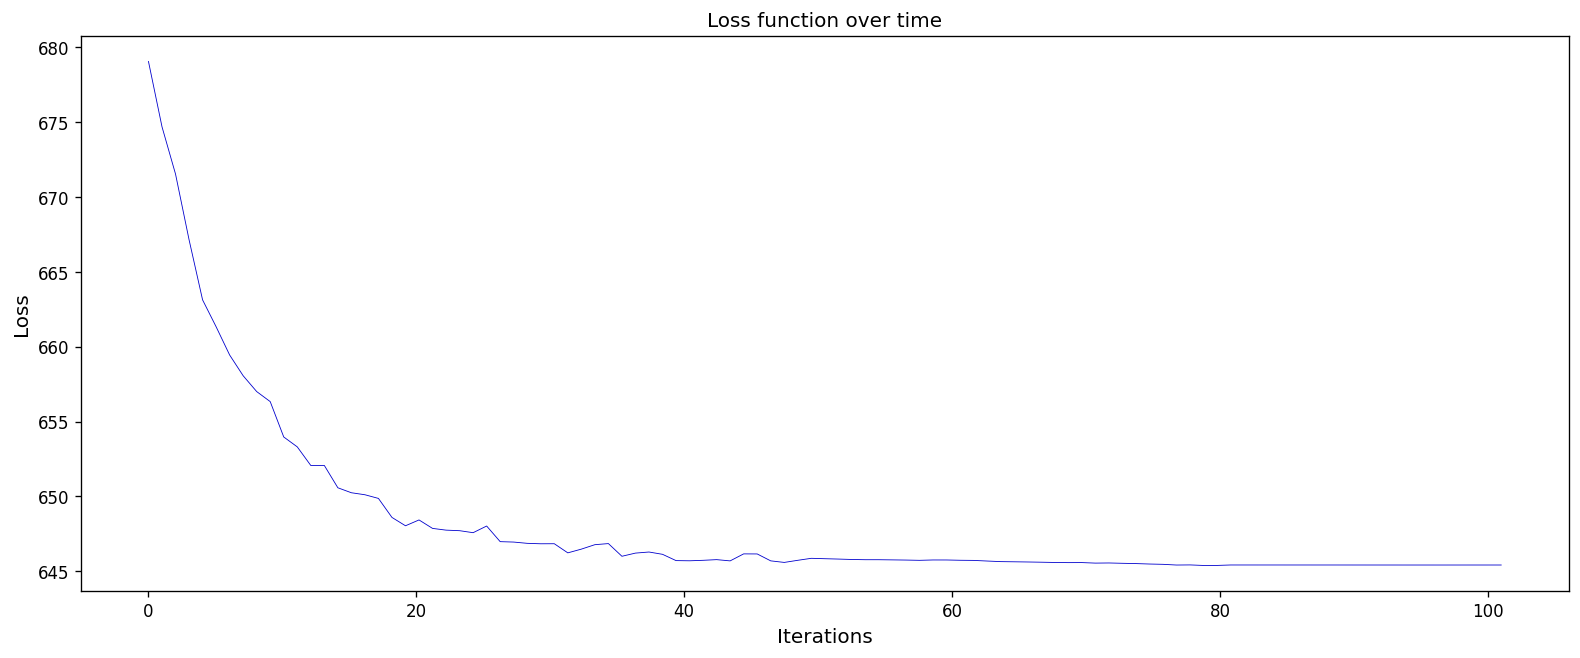

In [81]:
t = np.linspace(0, len(average_cost), len(average_cost))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(t, average_cost, lw = 0.5, color = 'mediumblue', label = 'average_cost')
ax0.set_xlabel('Iterations', fontsize = 12)
ax0.set_ylabel('Loss', fontsize = 12)
ax0.set_title('Loss function over time', fontsize = 12)
plt.savefig('Loss function'+str(TEXT)+'.png')

[0.02779175 0.02779299 0.02777823 0.02776427 0.02774371 0.02771712
 0.02769019 0.02765639 0.02761496 0.02758404 0.02757424 0.02746606
 0.02733612 0.02722247 0.02695555 0.0268384  0.02665136 0.02591141
 0.02591949 0.02534561 0.02538664 0.02526534 0.02482768 0.02435641
 0.02412217 0.02352314 0.02261692 0.02261592 0.02128269 0.02060322
 0.02032331 0.01979005 0.0190228  0.01814439 0.01751047 0.01681677
 0.01551293 0.01451532 0.01407642 0.0138191  0.0128032  0.01191537
 0.01170821 0.01124281 0.01044382 0.00979198 0.00908299 0.00847831
 0.00730238 0.00635335 0.00582204 0.00531357 0.00483526 0.00456062
 0.00439033 0.00430536 0.00426827 0.00425405 0.0042526  0.00424784]


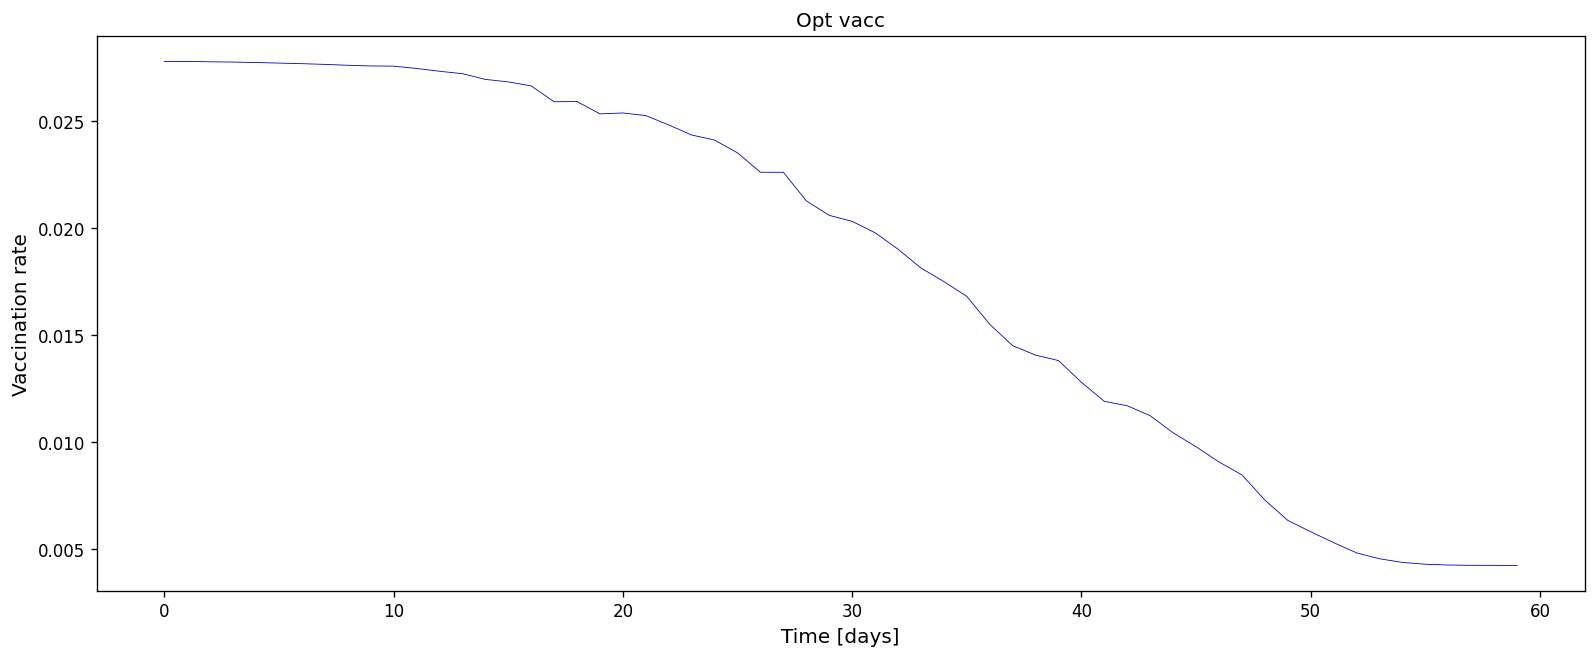

In [82]:
print(control_outs_table[1:2,:].flatten())
t = np.linspace(0, len(control_outs_table[1:2,:].flatten()),len(control_outs_table[1:2,:].flatten()))
fig, ax0 = plt.subplots(1, 1, figsize =(16,6), dpi = 120, sharey = True)
ax0.plot(control_outs_table[1:2,:].flatten(), lw = 0.5, color = 'mediumblue', label = 'average_cost')
ax0.set_xlabel('Time [days]', fontsize = 12)
ax0.set_ylabel('Vaccination rate', fontsize = 12)
ax0.set_title('Opt vacc', fontsize = 12)
plt.savefig('Opt vacc'+str(TEXT)+'.png')